1. DOUBLE IMBALANCE RESOLUTION (Threshold Check)


Sentiment,Negative,Neutral,Positive,All
TargetAspect,,,,
Ambiance and Atmosphere,250,144,1903,2297
Customer Service,616,244,2368,3228
Facilities and Amenities,250,130,1057,1437
Price and Value,250,102,610,962
Product Quality,836,570,6321,7727
Store Operations and Accessibility,250,80,653,983
All,2452,1270,12912,16634



2. SYNTHETIC RATIO VALIDATION (Model Collapse Defense)


,Synthetic Data %
TargetAspect,
Ambiance and Atmosphere,6.01%
Customer Service,0.0%
Facilities and Amenities,6.47%
Price and Value,13.1%
Product Quality,0.0%
Store Operations and Accessibility,13.94%



3. LEXICAL DRIFT / LENGTH CHECK (Structural Defense)


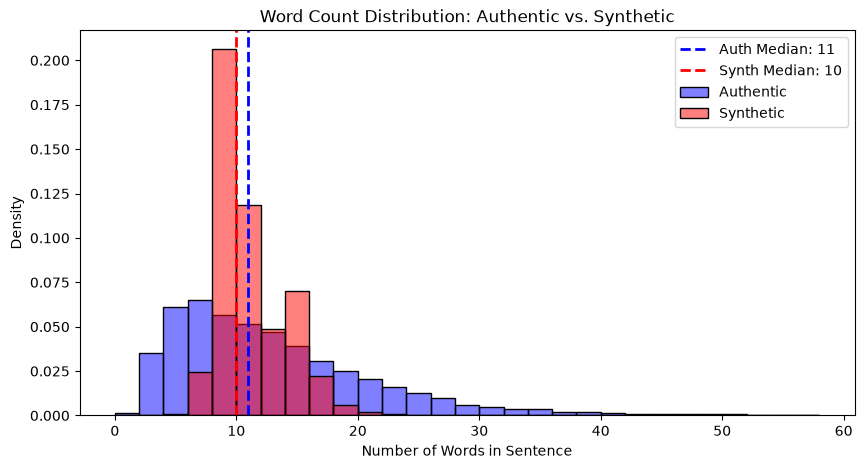

In [1]:
import pandas as pd                                                                                                                                                                                                                                    
import matplotlib.pyplot as plt                                                                                                                                                                                                                        
import seaborn as sns                                                                                                                                                                                                                                  
                                                                                                                                                                                                                                                        
# Load Augmented Data                                                                                                                                                                                                                                  
df = pd.read_csv('Train_Set_70_Augmented.csv')                                                                                                                                                                                                         
                                                                                                                                                                                                                                                        
# Safely map ratings to Sentiment (defaulting synthetic blanks to 'Negative')                                                                                                                                                                          
def safe_map_sentiment(row):                                                                                                                                                                                                                           
    try:                                                                                                                                                                                                                                               
        r = float(row['rating'])                                                                                                                                                                                                                       
        if r <= 2: return 'Negative'                                                                                                                                                                                                                   
        elif r == 3: return 'Neutral'                                                                                                                                                                                                                  
        else: return 'Positive'                                                                                                                                                                                                                        
    except:                                                                                                                                                                                                                                            
        return 'Negative' if row['is_synthetic'] else 'Unknown'                                                                                                                                                                                        
                                                                                                                                                                                                                                                        
df['Sentiment'] = df.apply(safe_map_sentiment, axis=1)                                                                                                                                                                                                 
                                                                                                                                                                                                                                                        
print("="*60)                                                                                                                                                                                                                                          
print("1. DOUBLE IMBALANCE RESOLUTION (Threshold Check)")                                                                                                                                                                                              
print("="*60)                                                                                                                                                                                                                                          
# Cross-tabulate Aspect by Sentiment                                                                                                                                                                                                                   
crosstab = pd.crosstab(df['TargetAspect'], df['Sentiment'], margins=True)                                                                                                                                                                              
display(crosstab)                                                                                                                                                                                                                                      
                                                                                                                                                                                                                                                        
print("\n" + "="*60)                                                                                                                                                                                                                                   
print("2. SYNTHETIC RATIO VALIDATION (Model Collapse Defense)")                                                                                                                                                                                        
print("="*60)                                                                                                                                                                                                                                          
# Calculate exact synthetic percentage per aspect                                                                                                                                                                                                      
df['is_synthetic'] = df['is_synthetic'].astype(bool)                                                                                                                                                                                                   
synthetic_ratios = df.groupby('TargetAspect')['is_synthetic'].mean() * 100                                                                                                                                                                             
synthetic_ratios_df = pd.DataFrame({'Synthetic Data %': synthetic_ratios.round(2).astype(str) + '%'})                                                                                                                                                  
display(synthetic_ratios_df)                                                                                                                                                                                                                           
                                                                                                                                                                                                                                                        
print("\n" + "="*60)                                                                                                                                                                                                                                   
print("3. LEXICAL DRIFT / LENGTH CHECK (Structural Defense)")                                                                                                                                                                                          
print("="*60)                                                                                                                                                                                                                                          
# Calculate word counts                                                                                                                                                                                                                                
df['word_count'] = df['sentence'].fillna('').astype(str).apply(lambda x: len(x.split()))                                                                                                                                                               
                                                                                                                                                                                                                                                        
# Isolate lengths                                                                                                                                                                                                                                      
auth_lengths = df[~df['is_synthetic']]['word_count']                                                                                                                                                                                                   
synth_lengths = df[df['is_synthetic']]['word_count']                                                                                                                                                                                                   
                                                                                                                                                                                                                                                        
# Plot Overlapping Histograms                                                                                                                                                                                                                          
plt.figure(figsize=(10, 5))                                                                                                                                                                                                                            
sns.histplot(auth_lengths, color='blue', alpha=0.5, label='Authentic', bins=range(0, 60, 2), stat='density')                                                                                                                                           
sns.histplot(synth_lengths, color='red', alpha=0.5, label='Synthetic', bins=range(0, 60, 2), stat='density')                                                                                                                                           
                                                                                                                                                                                                                                                        
# Plot medians for visual anchor                                                                                                                                                                                                                       
plt.axvline(auth_lengths.median(), color='blue', linestyle='dashed', linewidth=2, label=f'Auth Median: {auth_lengths.median():.0f}')                                                                                                                   
plt.axvline(synth_lengths.median(), color='red', linestyle='dashed', linewidth=2, label=f'Synth Median: {synth_lengths.median():.0f}')                                                                                                                 
                                                                                                                                                                                                                                                        
plt.title('Word Count Distribution: Authentic vs. Synthetic')                                                                                                                                                                                          
plt.xlabel('Number of Words in Sentence')                                                                                                                                                                                                              
plt.ylabel('Density')                                                                                                                                                                                                                                  
plt.legend()                                                                                                                                                                                                                                           
plt.show()                    